# Finetune with LLaMA Factory

Please use a **free** Tesla T4 Colab GPU to run this!

Project homepage: https://github.com/hiyouga/LLaMA-Factory

## Install Dependencies

In [ ]:
%cd /content/
%rm -rf LLaMA-Factory
!git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git
%cd LLaMA-Factory
%ls
!pip install -e .[torch,bitsandbytes] -qU

/content
Cloning into 'LLaMA-Factory'...
remote: Enumerating objects: 353, done.
remote: Counting objects: 100% (353/353), done.
remote: Compressing objects: 100% (282/282), done.
remote: Total 353 (delta 95), reused 185 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (353/353), 9.72 MiB | 33.16 MiB/s, done.
Resolving deltas: 100% (95/95), done.
/content/LLaMA-Factory
assets/       evaluation/  MANIFEST.in     requirements.txt  tests/
CITATION.cff  examples/    pyproject.toml  scripts/
data/         LICENSE      README.md       setup.py
docker/       Makefile     README_zh.md    src/
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s e

### Check GPU environment

In [ ]:
import torch
try:
  assert torch.cuda.is_available() is True
except AssertionError:
  print("Please set up a GPU before using LLaMA Factory: https://medium.com/mlearning-ai/training-yolov4-on-google-colab-316f8fff99c6")

## Update Identity Dataset

In [ ]:
!pip install datasets -qU

In [ ]:
from datasets import load_dataset

# 1. 加载原始数据集
dataset = load_dataset(
    "ShengbinYue/DISC-Law-SFT",
    data_files="DISC-Law-SFT-Triplet-QA-released.jsonl"
)

# 2. 定义Alpaca格式转换函数
def convert_to_alpaca(batch_examples):
    return {
        # 为整个批次生成指令列表
        "instruction": ["根据中国法律知识回答以下问题"] * len(batch_examples["input"]),
        "input": batch_examples["input"],  # 直接传递批次输入
        "output": batch_examples["output"]
    }
# 3. 转换并清理字段
# 定义需要保留的列
keep_columns = ["instruction", "input", "output"]

# 执行转换（批处理提升效率）
dataset = dataset.map(
    convert_to_alpaca,
    batched=True,
    batch_size=1000,
    remove_columns=["id", "reference"]  # 显式删除多余字段
)

# 4. 分割数据集（90%训练，10%测试）
dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

# 5. 保存到LLaMA Factory数据目录
# 正确保存方式（移除encoding参数）
dataset.save_to_disk("/content/LLaMA-Factory/data/disc_law_sft")

Saving the dataset (0/1 shards):   0%|          | 0/20997 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2334 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_from_disk

# 加载保存的数据集
dataset = load_from_disk("/content/LLaMA-Factory/data/disc_law_sft")

# 验证中文编码
# 定义美化打印函数
def pretty_print_example(example, index=0):
    text = f"""
    {'='*40}
    [示例 {index + 1}]
    {'-'*40}
    instruction:
    {example['instruction']}

    input:
    {example['input']}

    output:
    {example['output']}
    {'='*40}
    """
    print(text.expandtabs(4))  # 自动缩进

# 打印前3个示例
for idx in range(1):
    pretty_print_example(dataset["train"][idx], idx)


    [示例 1]
    ----------------------------------------
    instruction: 
    根据中国法律知识回答以下问题
    
    input: 
    《商业银行法》第七十三条：商业银行有下列情形之一，对存款人或者其他客户造成财产损害的，应当承担支付迟延履行的利息以及其他民事责任:（一）无故拖延、拒绝支付存款本金和利息的；（二）违反票据承兑等结算业务规定，不予兑现，不予收付入账，压单、压票或者违反规定退票的；（三）非法查询、冻结、扣划个人储蓄存款或者单位存款的；（四）违反本法规定对存款人或者其他客户造成损害的其他行为。有前款规定情形的，由国务院银行业监督管理机构责令改正，有违法所得的，没收违法所得，违法所得五万元以上的，并处违法所得一倍以上五倍以下罚款；没有违法所得或者违法所得不足五万元的，处五万元以上五十万元以下罚款。
《商业银行法》第七十一条：商业银行不能支付到期债务，经国务院银行业监督管理机构同意，由人民法院依法宣告其破产。商业银行被宣告破产的，由人民法院组织国务院银行业监督管理机构等有关部门和有关人员成立清算组，进行清算。商业银行破产清算时，在支付清算费用、所欠职工工资和劳动保险费用后，应当优先支付个人储蓄存款的本金和利息。
《商业银行法》第七十二条：商业银行因解散、被撤销和被宣告破产而终止。
<问题>：
某商业银行因经营不善宣告破产清算，其中涉及存款人储蓄存款。

在商业银行破产清算时，如何支付个人储蓄存款的本金和利息？
    
    output: 
    根据《商业银行法》第七十一条，商业银行被宣告破产时，应当优先支付个人储蓄存款的本金和利息。因此，在商业银行破产清算时，个人储蓄存款的本金和利息将被优先支付。

此外，根据《商业银行法》第七十三条，商业银行若无故拖延或拒绝支付存款本金和利息，或者违反规定导致存款人财产损害，银行应承担支付迟延履行的利息以及其他民事责任。

因此，根据相应法律规定，在商业银行破产清算时，个人储蓄存款的本金和利息应当被优先支付，并且商业银行应负责支付迟延履行的利息和其他民事责任，以保护存款人的权益。
    


In [ ]:
# 重命名文件（注意空格转义）
!cp "/content/LLaMA-Factory/data/disc_law_sft/dataset_dict.json" "/content/LLaMA-Factory/data/disc_law_sft/dataset_info.json"

In [ ]:
# 1. 加载 Arrow 格式数据集
dataset = load_from_disk("/content/LLaMA-Factory/data/disc_law_sft")

# 2. 保存为 JSON 格式
dataset["train"].to_json("/content/LLaMA-Factory/data/disc_law_sft_json/train.json")
dataset["test"].to_json("/content/LLaMA-Factory/data/disc_law_sft_json/test.json")

# 3. 创建新版 DatasetDict
from datasets import Dataset, DatasetDict

new_dataset = DatasetDict({
    "train": Dataset.from_json("/content/LLaMA-Factory/data/disc_law_sft_json/train.json"),
    "test": Dataset.from_json("/content/LLaMA-Factory/data/disc_law_sft_json/test.json")
})

# 4. 保存完整 DatasetDict（可选）
new_dataset.save_to_disk("/content/LLaMA-Factory/data/disc_law_sft_json")

Creating json from Arrow format:   0%|          | 0/21 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/20997 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2334 [00:00<?, ? examples/s]

In [ ]:
# 检查路径是否存在
!ls -l /content/LLaMA-Factory/data/disc_law_sft_json

total 110528
-rw-r--r-- 1 root root        29 Apr 18 22:21 dataset_dict.json
drwxr-xr-x 2 root root      4096 Apr 18 22:21 test
-rw-r--r-- 1 root root  11177816 Apr 18 22:21 test.json
drwxr-xr-x 2 root root      4096 Apr 18 22:21 train
-rw-r--r-- 1 root root 101984536 Apr 18 22:21 train.json


## Fine-tune model via Command Line

In [ ]:
import json

args = dict(
  stage="sft",                                               # do supervised fine-tuning
  do_train=True,
  model_name_or_path="Qwen/Qwen2.5-7B-Instruct",             # use bnb-4bit-quantized Llama-3-8B-Instruct model
  dataset="disc_law_sft",                                    # use alpaca and identity datasets
  template="chinese_law",                                         # use llama3 prompt template
  finetuning_type="lora",                                    # use LoRA adapters to save memory
  lora_target="c_attn,q_proj,v_proj",                        # attach LoRA adapters to all linear layers
  output_dir="llama3_lora_law",                              # the path to save LoRA adapters
  per_device_train_batch_size=4,                             # the micro batch size
  gradient_accumulation_steps=4,                             # the gradient accumulation steps
  lr_scheduler_type="cosine",                                # use cosine learning rate scheduler
  logging_steps=5,                                           # log every 5 steps
  warmup_ratio=0.1,                                          # use warmup scheduler
  save_steps=100,                                           # save checkpoint every 1000 steps
  learning_rate=3e-5,                                        # the learning rate
  num_train_epochs=0.5,                                      # the epochs of training
  max_samples=None,                                           # use 500 examples in each dataset
  max_grad_norm=1.0,                                         # clip gradient norm to 1.0
  loraplus_lr_ratio=16.0,                                    # use LoRA+ algorithm with lambda=16.0
  fp16=True,                                                 # use float16 mixed precision training
  report_to="none",                                          # disable wandb logging
  quantization_bit=8,
  # use_flash_attention_2=True
)

json.dump(args, open("train_llama3.json", "w", encoding="utf-8"), indent=2)

%cd /content/LLaMA-Factory/

!llamafactory-cli train train_llama3.json

/content/LLaMA-Factory
2025-04-18 23:18:38.677112: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745018318.706131   42158 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745018318.716083   42158 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-18 23:18:38.752909: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[WARNING|2025-04-18 23:18:46] llamafactory.hparams.parser:148 >> We recommend enable `upcast_layernorm

## Infer the fine-tuned model

In [ ]:
from llamafactory.chat import ChatModel
from llamafactory.extras.misc import torch_gc

%cd /content/LLaMA-Factory/

args = dict(
  model_name_or_path="Qwen/Qwen2.5-7B-Instruct",         # use bnb-4bit-quantized Llama-3-8B-Instruct model
  # adapter_name_or_path="llama3_lora_law",                        # load the saved LoRA adapters
  template="chinese_law",                                         # same to the one in training
  # finetuning_type="lora",                                    # same to the one in training
)
chat_model = ChatModel(args)

torch_gc()

[INFO|tokenization_utils_base.py:2060] 2025-04-19 00:41:38,895 >> loading file vocab.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/vocab.json
[INFO|tokenization_utils_base.py:2060] 2025-04-19 00:41:38,896 >> loading file merges.txt from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/merges.txt
[INFO|tokenization_utils_base.py:2060] 2025-04-19 00:41:38,897 >> loading file tokenizer.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/tokenizer.json
[INFO|tokenization_utils_base.py:2060] 2025-04-19 00:41:38,898 >> loading file added_tokens.json from cache at None
[INFO|tokenization_utils_base.py:2060] 2025-04-19 00:41:38,900 >> loading file special_tokens_map.json from cache at None
[INFO|tokenization_utils_base.py:2060] 2025-04-19 00:41:38,901 >> l

/content/LLaMA-Factory


[INFO|tokenization_utils_base.py:2323] 2025-04-19 00:41:39,321 >> Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
[INFO|configuration_utils.py:693] 2025-04-19 00:41:39,655 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/config.json
[INFO|configuration_utils.py:765] 2025-04-19 00:41:39,657 >> Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 3584,
  "initializer_range": 0.02,
  "intermediate_size": 18944,
  "max_position_embeddings": 32768,
  "max_window_layers": 28,
  "model_type": "qwen2",
  "num_attention_heads": 28,
  "num_hidden_layers": 28,
  "num_key_value_heads": 4,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sl

[INFO|2025-04-19 00:41:40] llamafactory.data.template:143 >> Add <问题>,
法律依据：,<|endoftext|> to stop words.
[WARNING|2025-04-19 00:41:40] llamafactory.data.template:148 >> New tokens have been added, make sure `resize_vocab` is True.


[INFO|configuration_utils.py:693] 2025-04-19 00:41:40,446 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/config.json
[INFO|configuration_utils.py:765] 2025-04-19 00:41:40,448 >> Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 3584,
  "initializer_range": 0.02,
  "intermediate_size": 18944,
  "max_position_embeddings": 32768,
  "max_window_layers": 28,
  "model_type": "qwen2",
  "num_attention_heads": 28,
  "num_hidden_layers": 28,
  "num_key_value_heads": 4,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sliding_window": 131072,
  "tie_word_embeddings": false,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.51.3",
  "use_cache": true,
  "use_sliding_window": false,
  "vocab_siz

[INFO|2025-04-19 00:41:40] llamafactory.model.model_utils.kv_cache:143 >> KV cache is enabled for faster generation.


[INFO|modeling_utils.py:1124] 2025-04-19 00:41:40,451 >> loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/model.safetensors.index.json
[INFO|modeling_utils.py:2167] 2025-04-19 00:41:40,460 >> Instantiating Qwen2ForCausalLM model under default dtype torch.bfloat16.
[INFO|configuration_utils.py:1142] 2025-04-19 00:41:40,464 >> Generate config GenerationConfig {
  "bos_token_id": 151643,
  "eos_token_id": 151645
}



Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO|modeling_utils.py:4930] 2025-04-19 00:41:47,932 >> All model checkpoint weights were used when initializing Qwen2ForCausalLM.

[INFO|modeling_utils.py:4938] 2025-04-19 00:41:47,933 >> All the weights of Qwen2ForCausalLM were initialized from the model checkpoint at Qwen/Qwen2.5-7B-Instruct.
If your task is similar to the task the model of the checkpoint was trained on, you can already use Qwen2ForCausalLM for predictions without further training.
[INFO|configuration_utils.py:1097] 2025-04-19 00:41:48,023 >> loading configuration file generation_config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/generation_config.json
[INFO|configuration_utils.py:1142] 2025-04-19 00:41:48,024 >> Generate config GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.05,
  "temperature": 0.7,
  "top_k":

[INFO|2025-04-19 00:41:48] llamafactory.model.model_utils.attention:143 >> Using torch SDPA for faster training and inference.
[INFO|2025-04-19 00:41:48] llamafactory.model.loader:143 >> all params: 7,615,616,512


In [ ]:
from datasets import load_from_disk
import random
from tabulate import tabulate

try:
    dataset = load_from_disk("/content/LLaMA-Factory/data/disc_law_sft")
    test_dataset = dataset["test"]
except Exception as e:
    print(f"数据集加载失败：{str(e)}")
    exit()

random.seed(42)
sampled_indices = random.sample(range(len(test_dataset)), 5)
samples = [test_dataset[i] for i in sampled_indices]

def model_inference(question: str) -> str:
    """包装现有的聊天模型接口"""
    messages = [{"role": "user", "content": question}]
    response = ""
    try:
        for new_text in chat_model.stream_chat(messages):
            response += new_text
    except Exception as e:
        response = f"推理错误：{str(e)}"
    return response

table_data = []
for idx, sample in enumerate(samples, 1):
    pred_answer = model_inference(sample["input"])

    table_row = [
        f"案例 {idx}",
        sample["input"].split("<问题>")[-1].strip(),
        pred_answer,
        sample["output"]
    ]
    table_data.append(table_row)

headers = ["ID", "法律问题", "模型回答", "参考答案"]
print("\n" + "="*80)
print(f"{'法律问答测试结果对比':^80}")
print("="*80)
print(tabulate(table_data,
             headers=headers,
             tablefmt="grid",
             maxcolwidths=[None, 30, 40, 40],
             stralign="left",
             numalign="center"))


                                   法律问答测试结果对比                                   
+--------+--------------------------------+------------+------------------------------------------+
| ID     | 法律问题                       | 模型回答   | 参考答案                                 |
+========+================================+============+==========================================+
| 案例 1 | ： 小红是一名女学生，在学校里  |            | 根据《妇女权益保障法》第二十三条，禁止违 |
|        | 受到了性骚扰，感到非常不安。她 |            | 背妇女意愿，以言语、文字、图像、肢体行为 |
|        | 想知道该如何维护自己的权益。   |            | 等方式对其实施性骚扰。因此，小红受到性骚 |
|        | 小红受到了性骚扰，该怎么办？   |            | 扰的行为是违法的。根据该法第二十四条，学 |
|        |                                |            | 校应当建立有效预防和科学处置性侵害、性骚 |
|        |                                |            | 扰的工作制度，并提供必要的保护措施。因此 |
|        |                                |            | ，小红可以向学校投诉，并要求学校采取相应 |
|        |                                |            | 的行动保护她的权益。受害妇女也有权向公安 |
|        |                                |      

In [ ]:
import matplotlib.pyplot as plt
print("可用样式列表:", plt.style.available)

可用样式列表: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取日志
log_path = "/content/LLaMA-Factory/llama3_lora_law/trainer_log.jsonl"
logs = pd.read_json(log_path, lines=True)

print(logs.head())

   current_steps  total_steps    loss        lr     epoch  percentage  \
0              5          656  4.0307  0.000002  0.003810        0.76   
1             10          656  3.3327  0.000004  0.007619        1.52   
2             15          656  2.0143  0.000006  0.011429        2.29   
3             20          656  1.0590  0.000009  0.015238        3.05   
4             25          656  0.3985  0.000011  0.019048        3.81   

         elapsed_time      remaining_time  
0 2025-04-19 00:00:31 2025-04-19 01:09:12  
1 2025-04-19 00:01:02 2025-04-19 01:07:37  
2 2025-04-19 00:01:34 2025-04-19 01:07:21  
3 2025-04-19 00:02:06 2025-04-19 01:07:08  
4 2025-04-19 00:02:39 2025-04-19 01:06:58  


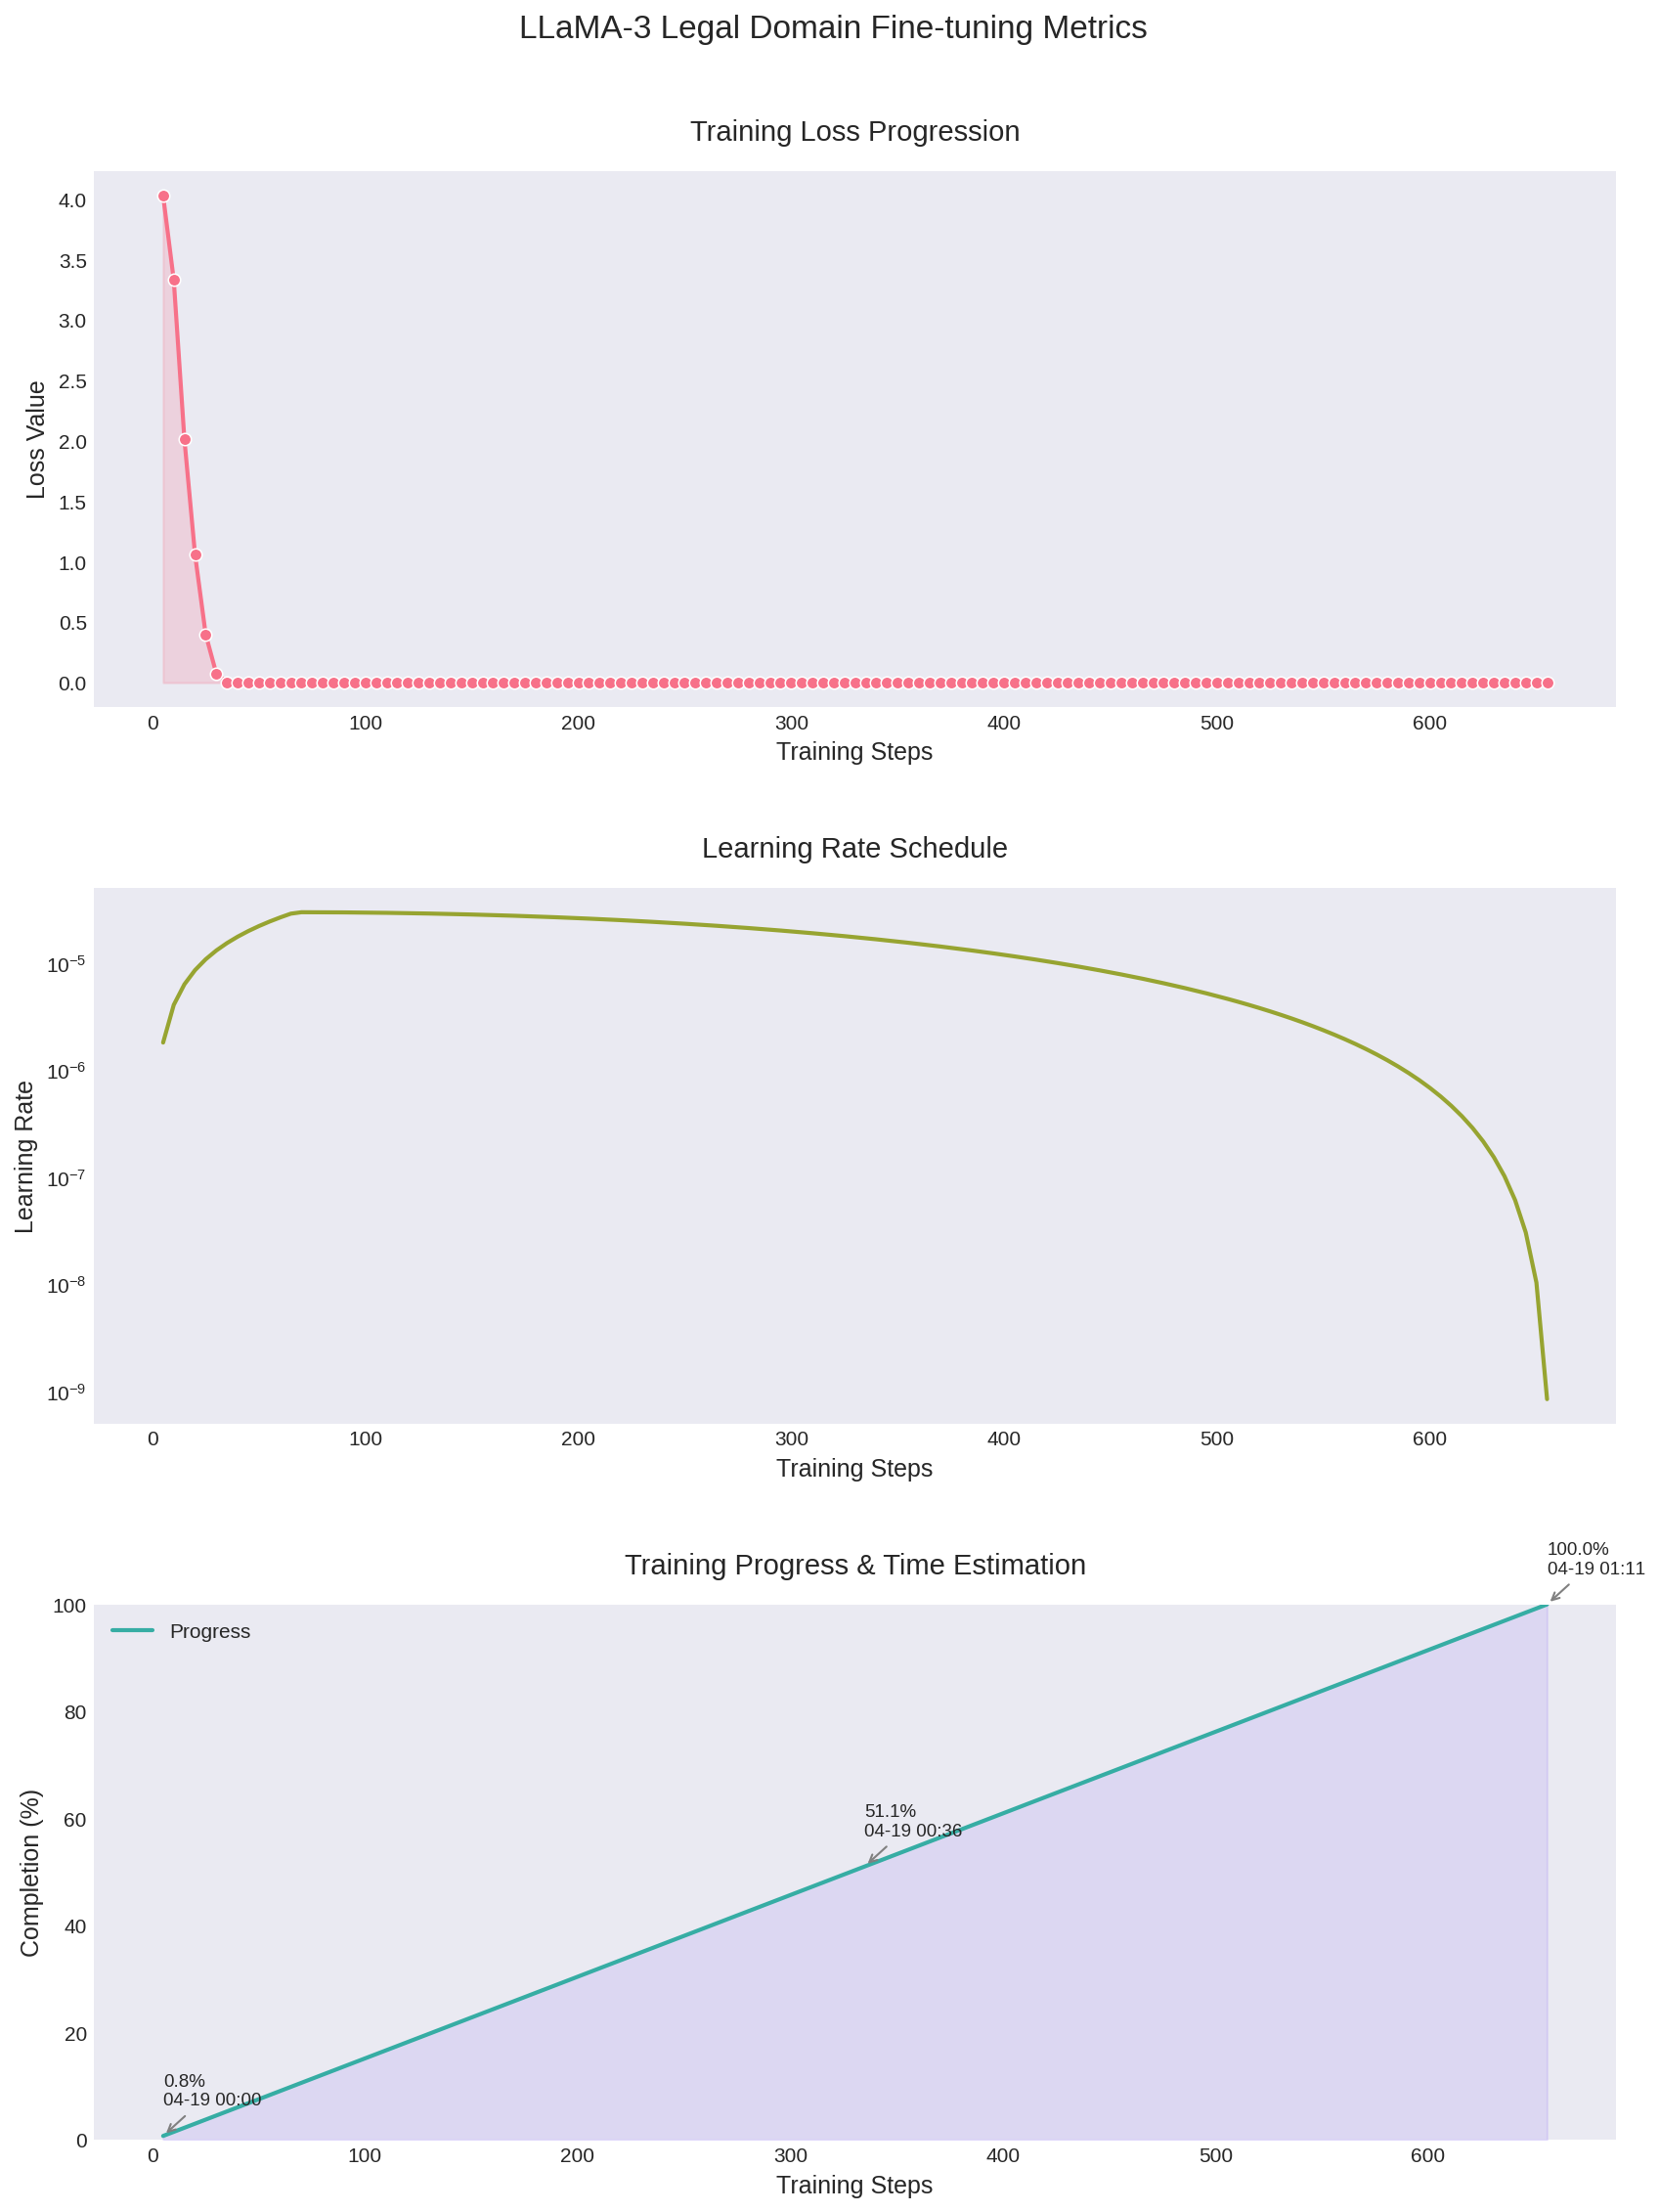

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ================== 1. 数据加载与预处理 ==================
# 正确读取JSON Lines格式日志
log_path = "/content/LLaMA-Factory/llama3_lora_law/trainer_log.jsonl"
logs = pd.read_json(log_path, lines=True)

# 时间数据转换
logs['elapsed_time'] = pd.to_datetime(logs['elapsed_time'])
logs['remaining_time'] = pd.to_datetime(logs['remaining_time'])

# 计算相对时间（小时）
logs['elapsed_hours'] = (logs['elapsed_time'] - logs['elapsed_time'].min()).dt.total_seconds()/3600
logs['remaining_hours'] = (logs['remaining_time'] - logs['remaining_time'].min()).dt.total_seconds()/3600

# ================== 2. 可视化样式配置 ==================
plt.style.use('seaborn-v0_8-dark')
palette = sns.color_palette("husl", 4)
fig, axs = plt.subplots(3, 1, figsize=(12, 15), dpi=150)

# ================== 3. 训练损失曲线 ==================
sns.lineplot(x='current_steps', y='loss', data=logs,
             color=palette[0], linewidth=2, marker='o', markersize=6, ax=axs[0])
axs[0].set_title('Training Loss Progression', fontsize=14, pad=15)
axs[0].set_xlabel('Training Steps', fontsize=12)
axs[0].set_ylabel('Loss Value', fontsize=12)
axs[0].fill_between(logs['current_steps'], logs['loss'], alpha=0.2, color=palette[0])

# ================== 4. 学习率变化曲线 ==================
sns.lineplot(x='current_steps', y='lr', data=logs,
             color=palette[1], linewidth=2, ax=axs[1])
axs[1].set_title('Learning Rate Schedule', fontsize=14, pad=15)
axs[1].set_xlabel('Training Steps', fontsize=12)
axs[1].set_ylabel('Learning Rate', fontsize=12)
axs[1].set_yscale('log')  # 对数坐标更清晰显示变化

# ================== 5. 训练进度可视化 ==================
# 进度曲线
sns.lineplot(x='current_steps', y='percentage', data=logs,
            color=palette[2], linewidth=2, label='Progress', ax=axs[2])

# 时间预测填充
axs[2].fill_between(logs['current_steps'],
                   logs['percentage'],
                   alpha=0.2, color=palette[3])

# 添加时间标注
for idx in [0, len(logs)//2, -1]:
    axs[2].annotate(
        f"{logs['percentage'].iloc[idx]:.1f}%\n" +
        datetime.strftime(logs['elapsed_time'].iloc[idx], "%m-%d %H:%M"),
        xy=(logs['current_steps'].iloc[idx], logs['percentage'].iloc[idx]),
        xytext=(0, 15), textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color='gray'),
        fontsize=9
    )

axs[2].set_title('Training Progress & Time Estimation', fontsize=14, pad=15)
axs[2].set_xlabel('Training Steps', fontsize=12)
axs[2].set_ylabel('Completion (%)', fontsize=12)
axs[2].set_ylim(0, 100)

# ================== 6. 全局优化与保存 ==================
plt.tight_layout(pad=3.0)
plt.suptitle('LLaMA-3 Legal Domain Fine-tuning Metrics', y=1.02, fontsize=16)
plt.savefig('training_metrics.png', bbox_inches='tight', dpi=300)
plt.show()

## Merge the LoRA adapter and optionally upload model

NOTE: the Colab free version has merely 12GB RAM, where merging LoRA of a 8B model needs at least 18GB RAM, thus you **cannot** perform it in the free version.

In [ ]:
!huggingface-cli login

In [ ]:
import json

args = dict(
  model_name_or_path="Qwen/Qwen2.5-7B-Instruct",   # use official non-quantized Llama-3-8B-Instruct model
  adapter_name_or_path="llama3_lora_law",                       # load the saved LoRA adapters
  template="chinese_law",                                        # same to the one in training
  finetuning_type="lora",                                   # same to the one in training
  export_dir="llama3_lora_law_merged",                          # the path to save the merged model
  export_size=2,                                            # the file shard size (in GB) of the merged model
  export_device="auto",                                      # the device used in export, can be chosen from `cpu` and `auto`
  export_hub_model_id="jimchoi/Qwen2.5-7B-Instruct_DISC_Law_SFT",               # the Hugging Face hub ID to upload model
)

json.dump(args, open("merge_llama3.json", "w", encoding="utf-8"), indent=2)

%cd /content/LLaMA-Factory/

!llamafactory-cli export merge_llama3.json

In [ ]:
# 1. 安装zip工具
!apt-get update && apt-get install -y zip

# 2. 压缩整个工作区（排除缓存文件）
!zip -r /content/all_files.zip /content/ \
    -x "*/__pycache__/*" "*.ipynb_checkpoints*" "*.log" "*.tmp"

# 3. 生成下载链接
from google.colab import files
print("\n🔥 下载链接：")
print(f'files.download("/content/all_files.zip")')

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,433 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,697 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,788 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:13 http://archive.ubuntu.com/ubu

In [98]:
files.download("/content/all_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>